In [29]:
# ============================================================
import os
import gc
import re
import math
import json
import random
from pathlib import Path
from contextlib import nullcontext

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)


PyTorch: 2.10.0+cu128


In [30]:
# ============================================================
DATASET_TAG = "desync100"       # "fixed", "desync50", or "desync100"
ASCAD_PATH_OVERRIDE = None      # example: "/kaggle/input/.../ASCAD_desync50.h5"

RUN_MODE = "standard"          # "debug", "standard", or "final"
RESUME = True

SEED = 42
TARGET_BYTE = 2                 # ASCAD target byte used in the uploaded TransNet code

# Architecture/training mode.
MODEL_FAMILY = "yolo_gated_hdt" # YOLO-augmented HDT, gated residual fusion
NORM_MODE = "global"            # "global", "none", or "trace"

# No heavy shift augmentation. The ASCAD desync files are already desynchronised.
AUG_SHIFT = 0
AUG_NOISE_STD = 0.0
AUG_AMP_STD = 0.02
AUG_OFFSET_STD = 0.01

# Effective batch 256 by default. Lower TRAIN_BATCH_SIZE if OOM and increase GRAD_ACCUM_STEPS.
# This hybrid is larger than the pure HDT, so 64x4 is the safer default.
TRAIN_BATCH_SIZE = 64
GRAD_ACCUM_STEPS = 4
EFFECTIVE_BATCH_SIZE = TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS
EVAL_BATCH_SIZE = 128

# Dataloader workers: 0 is slower but stable in notebooks.
NUM_WORKERS = 0

if RUN_MODE == "debug":
    TRAIN_STEPS = 1000
    SAVE_EVERY_STEPS = 500
    LR_DECAY_STEPS = 12000 if DATASET_TAG != "desync100" else 100000
    N_RANK_REPEATS = 5
    ATTACK_TRACES_FOR_GE = 3000
elif RUN_MODE == "standard":
    TRAIN_STEPS = 12000 if DATASET_TAG != "desync100" else 20000
    SAVE_EVERY_STEPS = 2000
    LR_DECAY_STEPS = 30000 if DATASET_TAG != "desync100" else 40000
    N_RANK_REPEATS = 30
    ATTACK_TRACES_FOR_GE = 5000
elif RUN_MODE == "final":
    TRAIN_STEPS = 24000 if DATASET_TAG != "desync100" else 100000
    SAVE_EVERY_STEPS = 4000
    LR_DECAY_STEPS = TRAIN_STEPS
    N_RANK_REPEATS = 100
    ATTACK_TRACES_FOR_GE = 10000
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

# Optimisation.
LR = 8e-4
MIN_LR_RATIO = 0.03
WARMUP_STEPS = 500 if RUN_MODE != "debug" else 100
WEIGHT_DECAY = 2e-4
GRAD_CLIP = 1.0
USE_AMP_REQUESTED = True

# HDT transformer dimensions.
D_MODEL = 128
N_HEAD = 4
D_FF = 384
DROPOUT = 0.10
ATTN_DROPOUT = 0.08
WINDOW_SIZE = 50
HIGHRES_WINDOW_BLOCKS = 2
MID_WINDOW_BLOCKS = 1
GLOBAL_BLOCKS = 2
POOL_QUERIES = 4

# YOLO branch configuration.
TRACE_IMAGE_MODE = "raw_window3"     # raw + diff + smooth sliding-window image
YOLO_WINDOW_LEN = 64
YOLO_WINDOW_HOP = 8
YOLO_BASE_CH = 32
YOLO_TOKEN_DROPOUT = 0.05
YOLO_GATE_INIT = -7.0                 # sigmoid(-7) ~= 0.0009, so the model starts as near-pure HDT
YOLO_AUX_WEIGHT = 0.03
GATE_L1_WEIGHT = 1e-4                 # keeps YOLO residual small unless useful

# Optional initialization from the successful pure HDT checkpoint.
# This is the recommended mode: the hybrid starts as a near-identical HDT and YOLO can only help via the small gate.
INIT_FROM_HDT_CHECKPOINT = True
BASE_HDT_CKPT_OVERRIDE = "/kaggle/input/datasets/govindkag1/step-66k/step_66000.pt"         # example: "/kaggle/input/.../hdt_desync50.../step_12000.pt"
BASE_HDT_SOURCE_TAG = DATASET_TAG      # usually same dataset; if desync100 checkpoint is missing, code can fall back to desync50
ALLOW_DESYNC50_FALLBACK_FOR_HDT_INIT = True

# Auxiliary leakage heads. The final attack still uses 256-class logits.
HW_AUX_WEIGHT = 0.20
BIT_AUX_WEIGHT = 0.05

MODEL_TAG = (
    f"yologated_hdt_{DATASET_TAG}_{RUN_MODE}_"
    f"d{D_MODEL}_w{WINDOW_SIZE}_bs{TRAIN_BATCH_SIZE}x{GRAD_ACCUM_STEPS}_"
    f"norm-{NORM_MODE}_gate{YOLO_GATE_INIT}_aug{AUG_SHIFT}"
)

print("DATASET_TAG:", DATASET_TAG)
print("RUN_MODE:", RUN_MODE)
print("MODEL_TAG:", MODEL_TAG)
print("TRAIN_STEPS:", TRAIN_STEPS)
print("SAVE_EVERY_STEPS:", SAVE_EVERY_STEPS)
print("LR_DECAY_STEPS:", LR_DECAY_STEPS)
print("TRAIN_BATCH_SIZE:", TRAIN_BATCH_SIZE)
print("GRAD_ACCUM_STEPS:", GRAD_ACCUM_STEPS)
print("EFFECTIVE_BATCH_SIZE:", EFFECTIVE_BATCH_SIZE)
print("NORM_MODE:", NORM_MODE)
print("AUG_SHIFT:", AUG_SHIFT)
print("TRACE_IMAGE_MODE:", TRACE_IMAGE_MODE)
print("YOLO_WINDOW_LEN/HOP:", YOLO_WINDOW_LEN, YOLO_WINDOW_HOP)
print("INIT_FROM_HDT_CHECKPOINT:", INIT_FROM_HDT_CHECKPOINT)
print("USE_AMP_REQUESTED:", USE_AMP_REQUESTED)
print("RESUME:", RESUME)


DATASET_TAG: desync100
RUN_MODE: standard
MODEL_TAG: yologated_hdt_desync100_standard_d128_w50_bs64x4_norm-global_gate-7.0_aug0
TRAIN_STEPS: 20000
SAVE_EVERY_STEPS: 2000
LR_DECAY_STEPS: 40000
TRAIN_BATCH_SIZE: 64
GRAD_ACCUM_STEPS: 4
EFFECTIVE_BATCH_SIZE: 256
NORM_MODE: global
AUG_SHIFT: 0
TRACE_IMAGE_MODE: raw_window3
YOLO_WINDOW_LEN/HOP: 64 8
INIT_FROM_HDT_CHECKPOINT: True
USE_AMP_REQUESTED: True
RESUME: True


In [31]:
# ============================================================
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(USE_AMP_REQUESTED and torch.cuda.is_available())
AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("USE_AMP:", USE_AMP)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)


DEVICE: cuda
USE_AMP: True
GPU: Tesla T4
GPU memory GB: 14.56219482421875


In [32]:
# ============================================================
SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

HW_TABLE = np.array([bin(i).count("1") for i in range(256)], dtype=np.int64)
BIT_TABLE = np.array([[(i >> b) & 1 for b in range(8)] for i in range(256)], dtype=np.float32)

print("SBOX length:", len(SBOX))


SBOX length: 256


In [33]:
# ============================================================
def normalize_path_text(path):
    return str(path).lower().replace("_", "").replace("-", "").replace(" ", "")


def inspect_h5_candidate(path):
    try:
        with h5py.File(path, "r") as f:
            if "Profiling_traces" not in f or "Attack_traces" not in f:
                return None
            if "traces" not in f["Profiling_traces"] or "labels" not in f["Profiling_traces"]:
                return None
            if "traces" not in f["Attack_traces"] or "labels" not in f["Attack_traces"]:
                return None
            return {
                "path": str(path),
                "prof_shape": tuple(f["Profiling_traces/traces"].shape),
                "atk_shape": tuple(f["Attack_traces/traces"].shape),
                "has_meta": "metadata" in f["Profiling_traces"] and "metadata" in f["Attack_traces"],
            }
    except Exception:
        return None


def choose_ascad_path():
    if ASCAD_PATH_OVERRIDE is not None:
        path = Path(ASCAD_PATH_OVERRIDE)
        if not path.exists():
            raise FileNotFoundError(path)
        return str(path)

    search_roots = [Path("/kaggle/input"), Path("/mnt/data"), Path(".")]
    h5_files = []
    for root in search_roots:
        if root.exists():
            h5_files.extend(list(root.rglob("*.h5")))

    if len(h5_files) == 0:
        raise FileNotFoundError("No .h5 files found. Set ASCAD_PATH_OVERRIDE.")

    if DATASET_TAG == "fixed":
        wanted = [p for p in h5_files if "desync" not in normalize_path_text(p)]
    else:
        wanted = [p for p in h5_files if DATASET_TAG.lower() in normalize_path_text(p)]

    candidates = []
    for p in wanted:
        info = inspect_h5_candidate(p)
        if info is not None:
            candidates.append(info)

    if len(candidates) == 0:
        print("Found H5 files:")
        for p in h5_files:
            print(" -", p)
        raise FileNotFoundError(f"No ASCAD-like H5 matched DATASET_TAG={DATASET_TAG}")

    # Prefer canonical 50000 x 700 / 10000 x 700 files.
    def score(c):
        s = 0
        if c["prof_shape"] == (50000, 700): s -= 100
        if c["atk_shape"] == (10000, 700): s -= 100
        if c["has_meta"]: s -= 20
        return s

    candidates = sorted(candidates, key=score)
    print("Matching candidates:")
    for c in candidates:
        print(c)
    return candidates[0]["path"]


ASCAD_PATH = choose_ascad_path()
print("Using ASCAD_PATH:", ASCAD_PATH)

with h5py.File(ASCAD_PATH, "r") as f:
    X_prof = f["Profiling_traces/traces"][:].astype(np.float32)
    y_prof = f["Profiling_traces/labels"][:].astype(np.int64)
    meta_prof = f["Profiling_traces/metadata"][:]

    X_attack = f["Attack_traces/traces"][:].astype(np.float32)
    y_attack = f["Attack_traces/labels"][:].astype(np.int64)
    meta_attack = f["Attack_traces/metadata"][:]

print("X_prof:", X_prof.shape, X_prof.dtype, X_prof.min(), X_prof.max(), X_prof.mean(), X_prof.std())
print("X_attack:", X_attack.shape, X_attack.dtype, X_attack.min(), X_attack.max(), X_attack.mean(), X_attack.std())
print("y_prof:", y_prof.shape, "unique:", len(np.unique(y_prof)))
print("metadata fields:", meta_prof.dtype.names)


Matching candidates:
{'path': '/kaggle/input/datasets/govindkag1/ascad-dataset/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5', 'prof_shape': (50000, 700), 'atk_shape': (10000, 700), 'has_meta': True}
Using ASCAD_PATH: /kaggle/input/datasets/govindkag1/ascad-dataset/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5
X_prof: (50000, 700) float32 -66.0 47.0 -11.099548 26.114227
X_attack: (10000, 700) float32 -67.0 46.0 -11.061205 26.117954
y_prof: (50000,) unique: 256
metadata fields: ('plaintext', 'ciphertext', 'key', 'masks', 'desync')


In [34]:
# ============================================================
prof_plain = meta_prof["plaintext"][:, TARGET_BYTE].astype(np.uint8)
prof_key = meta_prof["key"][:, TARGET_BYTE].astype(np.uint8)
attack_plain = meta_attack["plaintext"][:, TARGET_BYTE].astype(np.uint8)
attack_key = meta_attack["key"][:, TARGET_BYTE].astype(np.uint8)

prof_expected = SBOX[np.bitwise_xor(prof_plain, prof_key)].astype(np.int64)
attack_expected = SBOX[np.bitwise_xor(attack_plain, attack_key)].astype(np.int64)

prof_match = float(np.mean(prof_expected == y_prof))
attack_match = float(np.mean(attack_expected == y_attack))
ATTACK_TRUE_KEY = int(attack_key[0])
attack_key_constant = bool(np.all(attack_key == ATTACK_TRUE_KEY))

print("Profiling label match:", prof_match)
print("Attack label match:", attack_match)
print("Attack true key:", ATTACK_TRUE_KEY)
print("Attack key constant:", attack_key_constant)

if prof_match < 0.999 or attack_match < 0.999:
    raise RuntimeError("Labels do not match SBOX[plaintext_byte xor key_byte]. Check TARGET_BYTE/dataset.")
if not attack_key_constant:
    raise RuntimeError("Attack target key is not constant; rank/GE would be invalid.")

label_counts = np.bincount(y_prof, minlength=256)
print("Label count min/max/mean:", label_counts.min(), label_counts.max(), label_counts.mean())
print("Random CE ln(256):", np.log(256.0))
print("Random accuracy:", 1/256)


Profiling label match: 1.0
Attack label match: 1.0
Attack true key: 224
Attack key constant: True
Label count min/max/mean: 154 244 195.3125
Random CE ln(256): 5.545177444479562
Random accuracy: 0.00390625


In [35]:
# ============================================================
if NORM_MODE == "global":
    norm_mean = np.array([X_prof.mean()], dtype=np.float32)
    norm_std = np.array([max(X_prof.std(), 1e-6)], dtype=np.float32)
elif NORM_MODE == "none":
    norm_mean = np.array([0.0], dtype=np.float32)
    norm_std = np.array([1.0], dtype=np.float32)
elif NORM_MODE == "trace":
    norm_mean = np.array([0.0], dtype=np.float32)
    norm_std = np.array([1.0], dtype=np.float32)
else:
    raise ValueError(f"Unknown NORM_MODE: {NORM_MODE}")

print("norm_mean:", norm_mean, "norm_std:", norm_std)


class ASCADTraceDataset(Dataset):
    def __init__(self, traces, labels, train=False):
        self.traces = traces.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.train = bool(train)

    def __len__(self):
        return len(self.traces)

    @staticmethod
    def shift_zero(x, shift):
        if shift == 0:
            return x
        y = np.zeros_like(x)
        if shift > 0:
            y[shift:] = x[:-shift]
        else:
            y[:shift] = x[-shift:]
        return y

    def normalise(self, x):
        if NORM_MODE == "global":
            x = (x - norm_mean[0]) / norm_std[0]
        elif NORM_MODE == "trace":
            x = (x - x.mean()) / max(x.std(), 1e-6)
        return x

    def __getitem__(self, idx):
        x = self.traces[idx].astype(np.float32)
        x = self.normalise(x)

        if self.train:
            if AUG_SHIFT > 0:
                shift = np.random.randint(-AUG_SHIFT, AUG_SHIFT + 1)
                x = self.shift_zero(x, shift)
            if AUG_AMP_STD > 0:
                x = x * np.float32(1.0 + np.random.normal(0.0, AUG_AMP_STD))
            if AUG_OFFSET_STD > 0:
                x = x + np.float32(np.random.normal(0.0, AUG_OFFSET_STD))
            if AUG_NOISE_STD > 0:
                x = x + np.random.normal(0.0, AUG_NOISE_STD, size=x.shape).astype(np.float32)

        y = int(self.labels[idx])
        hw = int(HW_TABLE[y])
        bits = BIT_TABLE[y]
        return (
            torch.from_numpy(x.astype(np.float32)),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(hw, dtype=torch.long),
            torch.from_numpy(bits.astype(np.float32)),
        )


train_ds = ASCADTraceDataset(X_prof, y_prof, train=True)
attack_ds = ASCADTraceDataset(X_attack, y_attack, train=False)

loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)

attack_loader = DataLoader(
    attack_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

print("Train batches:", len(train_loader))
print("Attack batches:", len(attack_loader))
xb, yb, hwb, bitb = next(iter(train_loader))
print("Batch:", xb.shape, yb.shape, hwb.shape, bitb.shape)
print("Batch trace mean/std:", float(xb.mean()), float(xb.std()))


norm_mean: [-11.099548] norm_std: [26.114227]
Train batches: 781
Attack batches: 79
Batch: torch.Size([64, 700]) torch.Size([64]) torch.Size([64]) torch.Size([64, 8])
Batch trace mean/std: 0.0005049138562753797 0.9974732398986816


In [36]:
# ============================================================
def stable_log_softmax_np(logits):
    z = logits.astype(np.float64)
    z = z - z.max(axis=1, keepdims=True)
    return z - np.log(np.exp(z).sum(axis=1, keepdims=True))


def rank_curve_from_log_probs(log_probs, plaintexts, true_key):
    key_scores = np.zeros(256, dtype=np.float64)
    ranks = np.zeros(len(log_probs), dtype=np.int64)
    key_candidates = np.arange(256, dtype=np.uint8)

    for i in range(len(log_probs)):
        pt = np.uint8(plaintexts[i])
        hyp_labels = SBOX[np.bitwise_xor(pt, key_candidates)]
        key_scores += log_probs[i, hyp_labels]
        true_score = key_scores[int(true_key)]
        ranks[i] = int(np.sum(key_scores > true_score))

    return ranks


def make_ge_indices(n_items, n_traces, n_repeats, seed):
    rng = np.random.default_rng(seed)
    n_traces = min(int(n_traces), int(n_items))
    return [rng.permutation(n_items)[:n_traces] for _ in range(int(n_repeats))]


def guessing_entropy_from_log_probs(log_probs, plaintexts, true_key, n_traces, n_repeats, seed):
    indices = make_ge_indices(len(log_probs), n_traces, n_repeats, seed)
    curves = []
    for idx in tqdm(indices, desc="GE repeats", leave=False):
        curve = rank_curve_from_log_probs(log_probs[idx], plaintexts[idx], true_key)
        curves.append(curve)
    curves = np.stack(curves, axis=0)
    return curves.mean(axis=0), curves.std(axis=0), curves


def metrics_from_ge(single_curve, ge_mean):
    if np.any(ge_mean < 1.0):
        t_ge = int(np.argmax(ge_mean < 1.0) + 1)
    else:
        t_ge = None
    if np.any(single_curve == 0):
        t_rank0 = int(np.argmax(single_curve == 0) + 1)
    else:
        t_rank0 = None
    return {
        "single_final_rank": int(single_curve[-1]),
        "single_min_rank": int(single_curve.min()),
        "single_traces_to_rank0": t_rank0,
        "ge_final": float(ge_mean[-1]),
        "ge_min": float(ge_mean.min()),
        "traces_to_ge_below_1": t_ge,
    }


In [37]:
# ============================================================
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps
    def forward(self, x):
        dtype = x.dtype
        y = x.float()
        y = y * torch.rsqrt(y.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return (y.to(dtype) * self.weight)


class MultiScaleStem(nn.Module):
    def __init__(self, in_ch=3, d_model=128, dropout=0.05):
        super().__init__()
        branch = d_model // 4
        self.branches = nn.ModuleList([
            nn.Conv1d(in_ch, branch, kernel_size=7, padding=3, bias=False),
            nn.Conv1d(in_ch, branch, kernel_size=15, padding=7, bias=False),
            nn.Conv1d(in_ch, branch, kernel_size=31, padding=15, bias=False),
            nn.Conv1d(in_ch, branch, kernel_size=51, padding=25, bias=False),
        ])
        self.fuse = nn.Sequential(
            nn.GroupNorm(8, branch * 4),
            nn.GELU(),
            nn.Conv1d(branch * 4, d_model, kernel_size=1, bias=False),
            nn.GroupNorm(8, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        x = torch.cat([b(x) for b in self.branches], dim=1)
        return self.fuse(x)


class ResidualDWConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=15, dilation=1, dropout=0.05, expansion=2):
        super().__init__()
        padding = (kernel_size // 2) * dilation
        hidden = channels * expansion
        self.net = nn.Sequential(
            nn.GroupNorm(8, channels),
            nn.Conv1d(channels, hidden, kernel_size=1, bias=False),
            nn.GELU(),
            nn.Conv1d(hidden, hidden, kernel_size=kernel_size, padding=padding,
                      dilation=dilation, groups=hidden, bias=False),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1, bias=False),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return x + self.net(x)


class DownsampleTokens(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv1d(dim, dim, kernel_size=5, stride=2, padding=2, bias=False)
        self.norm = nn.GroupNorm(8, dim)
        self.act = nn.GELU()
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.act(self.norm(self.conv(x)))
        return x.transpose(1, 2)


class WindowAttentionBlock(nn.Module):
    def __init__(self, dim, n_head=4, window_size=50, dropout=0.10, attn_dropout=0.08, shift=False):
        super().__init__()
        assert dim % n_head == 0
        self.dim = dim
        self.n_head = n_head
        self.head_dim = dim // n_head
        self.window_size = int(window_size)
        self.shift = bool(shift)
        self.shift_size = self.window_size // 2 if self.shift else 0
        self.norm1 = RMSNorm(dim)
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.rel_bias = nn.Parameter(torch.zeros(n_head, self.window_size, self.window_size))
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(dim, dim, bias=False)
        self.proj_drop = nn.Dropout(dropout)
        self.norm2 = RMSNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * dim, dim),
            nn.Dropout(dropout),
        )
        nn.init.trunc_normal_(self.rel_bias, std=0.02)

    def partition_windows(self, x):
        B, L, D = x.shape
        pad_len = (self.window_size - L % self.window_size) % self.window_size
        if pad_len > 0:
            x = F.pad(x, (0, 0, 0, pad_len))
        Lp = x.shape[1]
        x = x.view(B, Lp // self.window_size, self.window_size, D)
        x = x.reshape(B * (Lp // self.window_size), self.window_size, D)
        return x, L, Lp

    def merge_windows(self, xw, B, L, Lp):
        x = xw.view(B, Lp // self.window_size, self.window_size, self.dim)
        x = x.reshape(B, Lp, self.dim)
        return x[:, :L, :]

    def forward(self, x):
        B, L, D = x.shape
        residual = x
        y = self.norm1(x)
        if self.shift_size > 0 and L > self.window_size:
            y = torch.roll(y, shifts=-self.shift_size, dims=1)
        y, orig_L, Lp = self.partition_windows(y)
        qkv = self.qkv(y).view(y.shape[0], self.window_size, 3, self.n_head, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn + self.rel_bias.unsqueeze(0).to(attn.dtype)
        attn = torch.softmax(attn.float(), dim=-1).to(attn.dtype)
        attn = self.attn_drop(attn)
        out = attn @ v
        out = out.transpose(1, 2).reshape(y.shape[0], self.window_size, D)
        out = self.proj_drop(self.proj(out))
        out = self.merge_windows(out, B, orig_L, Lp)
        if self.shift_size > 0 and L > self.window_size:
            out = torch.roll(out, shifts=self.shift_size, dims=1)
        x = residual + out
        x = x + self.mlp(self.norm2(x))
        return x


class RelativeGlobalAttentionBlock(nn.Module):
    def __init__(self, dim, n_head=4, dropout=0.10, attn_dropout=0.08, max_len=512):
        super().__init__()
        assert dim % n_head == 0
        self.dim = dim
        self.n_head = n_head
        self.head_dim = dim // n_head
        self.max_len = int(max_len)
        self.norm1 = RMSNorm(dim)
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.rel_bias_table = nn.Parameter(torch.zeros(n_head, 2 * max_len - 1))
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj = nn.Linear(dim, dim, bias=False)
        self.proj_drop = nn.Dropout(dropout)
        self.norm2 = RMSNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, D_FF),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(D_FF, dim),
            nn.Dropout(dropout),
        )
        nn.init.trunc_normal_(self.rel_bias_table, std=0.02)

    def relative_bias(self, L, device):
        if L > self.max_len:
            raise ValueError(f"Sequence length {L} exceeds max_len {self.max_len}")
        pos = torch.arange(L, device=device)
        rel = pos[:, None] - pos[None, :]
        rel = rel.clamp(-(self.max_len - 1), self.max_len - 1) + self.max_len - 1
        return self.rel_bias_table[:, rel]

    def forward(self, x):
        B, L, D = x.shape
        y = self.norm1(x)
        qkv = self.qkv(y).view(B, L, 3, self.n_head, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn + self.relative_bias(L, x.device).unsqueeze(0).to(attn.dtype)
        attn = torch.softmax(attn.float(), dim=-1).to(attn.dtype)
        attn = self.attn_drop(attn)
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, L, D)
        x = x + self.proj_drop(self.proj(out))
        x = x + self.mlp(self.norm2(x))
        return x


class MultiQueryPool(nn.Module):
    def __init__(self, dim, n_queries=4):
        super().__init__()
        self.queries = nn.Parameter(torch.randn(n_queries, dim) * 0.02)
        self.norm = RMSNorm(dim)
    def forward(self, x):
        y = self.norm(x)
        scores = torch.einsum("bld,qd->bql", y, self.queries) / math.sqrt(y.shape[-1])
        weights = torch.softmax(scores.float(), dim=-1).to(x.dtype)
        pooled = torch.einsum("bql,bld->bqd", weights, x)
        return pooled.reshape(x.shape[0], -1)


# ------------------------ YOLOv8-style 2D branch ------------------------
class ConvBNAct2D(nn.Module):
    def __init__(self, c1, c2, k=3, s=1, p=None):
        super().__init__()
        if p is None:
            p = k // 2
        self.conv = nn.Conv2d(c1, c2, kernel_size=k, stride=s, padding=p, bias=False)
        self.bn = nn.BatchNorm2d(c2)
        self.act = nn.SiLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class Bottleneck2D(nn.Module):
    def __init__(self, c, shortcut=True):
        super().__init__()
        hidden = max(c // 2, 8)
        self.cv1 = ConvBNAct2D(c, hidden, k=1, s=1)
        self.cv2 = ConvBNAct2D(hidden, c, k=3, s=1)
        self.shortcut = shortcut
    def forward(self, x):
        y = self.cv2(self.cv1(x))
        return x + y if self.shortcut else y


class C2f2D(nn.Module):
    def __init__(self, c1, c2, n=2):
        super().__init__()
        hidden = c2 // 2
        self.cv1 = ConvBNAct2D(c1, 2 * hidden, k=1, s=1)
        self.blocks = nn.ModuleList([Bottleneck2D(hidden, shortcut=True) for _ in range(n)])
        self.cv2 = ConvBNAct2D((2 + n) * hidden, c2, k=1, s=1)
    def forward(self, x):
        y = list(self.cv1(x).chunk(2, dim=1))
        for block in self.blocks:
            y.append(block(y[-1]))
        return self.cv2(torch.cat(y, dim=1))


class SPPF2D(nn.Module):
    def __init__(self, c1, c2, k=5):
        super().__init__()
        hidden = c1 // 2
        self.cv1 = ConvBNAct2D(c1, hidden, k=1, s=1)
        self.pool = nn.MaxPool2d(kernel_size=k, stride=1, padding=k // 2)
        self.cv2 = ConvBNAct2D(hidden * 4, c2, k=1, s=1)
    def forward(self, x):
        x = self.cv1(x)
        y1 = self.pool(x)
        y2 = self.pool(y1)
        y3 = self.pool(y2)
        return self.cv2(torch.cat([x, y1, y2, y3], dim=1))


class YoloTraceBranch(nn.Module):
    def __init__(self, out_dim=D_MODEL, base_ch=YOLO_BASE_CH, dropout=YOLO_TOKEN_DROPOUT):
        super().__init__()
        self.stem = ConvBNAct2D(3, base_ch, k=3, s=1)
        self.stage1 = C2f2D(base_ch, base_ch, n=1)
        self.down1 = ConvBNAct2D(base_ch, base_ch * 2, k=3, s=2)
        self.stage2 = C2f2D(base_ch * 2, base_ch * 2, n=2)
        self.down2 = ConvBNAct2D(base_ch * 2, base_ch * 4, k=3, s=2)
        self.stage3 = C2f2D(base_ch * 4, base_ch * 4, n=2)
        self.sppf = SPPF2D(base_ch * 4, base_ch * 4)
        self.to_dim = nn.Conv2d(base_ch * 4, out_dim, kernel_size=1, bias=False)
        self.norm = nn.BatchNorm2d(out_dim)
        self.drop = nn.Dropout(dropout)

    def trace_to_image(self, traces):
        # traces: [B, T], already normalized
        x = traces.unsqueeze(1)
        diff = torch.zeros_like(x)
        diff[:, :, 1:] = x[:, :, 1:] - x[:, :, :-1]
        smooth = F.avg_pool1d(x, kernel_size=5, stride=1, padding=2)
        chans = torch.cat([x, diff, smooth], dim=1)  # [B, 3, T]
        windows = chans.unfold(dimension=-1, size=YOLO_WINDOW_LEN, step=YOLO_WINDOW_HOP)
        # [B, 3, n_windows, window_len]
        return windows.contiguous()

    def forward(self, traces, target_len):
        img = self.trace_to_image(traces)
        z = self.stem(img)
        z = self.stage1(z)
        z = self.down1(z)
        z = self.stage2(z)
        z = self.down2(z)
        z = self.stage3(z)
        z = self.sppf(z)
        z = self.drop(F.silu(self.norm(self.to_dim(z))))  # [B, D, H, W]

        # Time-aligned YOLO tokens: average over window-width axis, interpolate over row/time axis.
        seq = z.mean(dim=-1)  # [B, D, H]
        seq = F.interpolate(seq.float(), size=target_len, mode="linear", align_corners=False).to(z.dtype)
        seq = seq.transpose(1, 2).contiguous()  # [B, target_len, D]

        pooled = z.mean(dim=(2, 3))  # [B, D]
        return seq, pooled


class YOLOGatedHDTFusionHybrid(nn.Module):
    def __init__(self):
        super().__init__()
        # Exact HDT temporal modules keep the same names as the pure HDT checkpoint.
        self.stem = MultiScaleStem(in_ch=3, d_model=D_MODEL, dropout=DROPOUT * 0.5)
        self.high_conv = nn.Sequential(
            ResidualDWConvBlock(D_MODEL, kernel_size=7, dilation=1, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=1, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=2, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=31, dilation=1, dropout=DROPOUT * 0.5),
        )
        self.high_attn = nn.ModuleList([
            WindowAttentionBlock(D_MODEL, N_HEAD, WINDOW_SIZE, DROPOUT, ATTN_DROPOUT, shift=(i % 2 == 1))
            for i in range(HIGHRES_WINDOW_BLOCKS)
        ])
        self.down1 = DownsampleTokens(D_MODEL)
        self.mid_conv = nn.Sequential(
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=1, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=2, dropout=DROPOUT * 0.5),
        )
        self.mid_attn = nn.ModuleList([
            WindowAttentionBlock(D_MODEL, N_HEAD, WINDOW_SIZE, DROPOUT, ATTN_DROPOUT, shift=(i % 2 == 1))
            for i in range(MID_WINDOW_BLOCKS)
        ])
        self.down2 = DownsampleTokens(D_MODEL)

        # YOLO spatial branch injects a gated residual into the final HDT token stream.
        self.yolo_branch = YoloTraceBranch(out_dim=D_MODEL, base_ch=YOLO_BASE_CH, dropout=YOLO_TOKEN_DROPOUT)
        self.yolo_token_norm = RMSNorm(D_MODEL)
        self.yolo_gate = nn.Parameter(torch.tensor(float(YOLO_GATE_INIT)))

        self.global_blocks = nn.ModuleList([
            RelativeGlobalAttentionBlock(D_MODEL, N_HEAD, DROPOUT, ATTN_DROPOUT, max_len=256)
            for _ in range(GLOBAL_BLOCKS)
        ])
        self.pool = MultiQueryPool(D_MODEL, POOL_QUERIES)
        feature_dim = D_MODEL * (POOL_QUERIES + 3)
        self.feature_norm = nn.LayerNorm(feature_dim)
        self.shared_head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )
        self.class_head = nn.Linear(256, 256)
        self.hw_head = nn.Linear(256, 9)
        self.bit_head = nn.Linear(256, 8)
        self.yolo_aux_head = nn.Linear(D_MODEL, 256)
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.Conv1d, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")

    def make_channels(self, traces):
        x = traces.unsqueeze(1)
        diff = torch.zeros_like(x)
        diff[:, :, 1:] = x[:, :, 1:] - x[:, :, :-1]
        smooth = F.avg_pool1d(x, kernel_size=5, stride=1, padding=2)
        return torch.cat([x, diff, smooth], dim=1)

    def temporal_tokens_before_global(self, traces):
        x = self.make_channels(traces)
        x = self.stem(x)
        x = self.high_conv(x)
        x = x.transpose(1, 2)
        for block in self.high_attn:
            x = block(x)
        x = self.down1(x)
        xc = x.transpose(1, 2)
        xc = self.mid_conv(xc)
        x = xc.transpose(1, 2)
        for block in self.mid_attn:
            x = block(x)
        x = self.down2(x)
        return x

    def classify_tokens(self, x):
        for block in self.global_blocks:
            x = block(x)
        qpool = self.pool(x)
        mean = x.mean(dim=1)
        maxv = x.amax(dim=1)
        std = x.std(dim=1, unbiased=False)
        features = torch.cat([qpool, mean, maxv, std], dim=1)
        features = self.feature_norm(features)
        shared = self.shared_head(features)
        logits = self.class_head(shared)
        return logits, shared

    def forward(self, traces, return_aux=False):
        x = self.temporal_tokens_before_global(traces)
        yolo_seq, yolo_pooled = self.yolo_branch(traces, target_len=x.shape[1])
        yolo_seq = self.yolo_token_norm(yolo_seq)
        gate = torch.sigmoid(self.yolo_gate).to(x.dtype)
        x = x + gate * yolo_seq
        logits, shared = self.classify_tokens(x)

        if return_aux:
            return {
                "logits": logits,
                "hw_logits": self.hw_head(shared),
                "bit_logits": self.bit_head(shared),
                "yolo_logits": self.yolo_aux_head(yolo_pooled),
                "yolo_gate": gate,
            }
        return logits


model = YOLOGatedHDTFusionHybrid().to(DEVICE)
num_params = sum(p.numel() for p in model.parameters())
print("Parameters:", f"{num_params:,}")
print("Initial YOLO gate sigmoid:", float(torch.sigmoid(model.yolo_gate).detach().cpu()))

with torch.no_grad():
    test_out = model(xb[:2].to(DEVICE), return_aux=True)
print("Logits:", test_out["logits"].shape, "HW:", test_out["hw_logits"].shape, "Bits:", test_out["bit_logits"].shape, "YOLO:", test_out["yolo_logits"].shape)


Parameters: 2,532,682
Initial YOLO gate sigmoid: 0.0009110511746257544
Logits: torch.Size([2, 256]) HW: torch.Size([2, 9]) Bits: torch.Size([2, 8]) YOLO: torch.Size([2, 256])


In [38]:
# ============================================================
CKPT_DIR = Path(f"/kaggle/working/{MODEL_TAG}_ckpt") if Path("/kaggle/working").exists() else Path(f"/mnt/data/{MODEL_TAG}_ckpt")
RESULT_DIR = Path(f"/kaggle/working/{MODEL_TAG}_results") if Path("/kaggle/working").exists() else Path(f"/mnt/data/{MODEL_TAG}_results")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print("CKPT_DIR:", CKPT_DIR)
print("RESULT_DIR:", RESULT_DIR)

criterion_cls = nn.CrossEntropyLoss()
criterion_hw = nn.CrossEntropyLoss()
criterion_bits = nn.BCEWithLogitsLoss()


def checkpoint_step_from_name(path):
    m = re.search(r"step_(\d+)", path.name)
    return int(m.group(1)) if m else -1


def find_hdt_base_checkpoint():
    if BASE_HDT_CKPT_OVERRIDE is not None:
        path = Path(BASE_HDT_CKPT_OVERRIDE)
        if not path.exists():
            raise FileNotFoundError(path)
        return path

    roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path("/mnt/data")]
    candidates = []
    wanted_tag = str(BASE_HDT_SOURCE_TAG).lower()
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob("*.pt"):
            s = str(p).lower()
            if "hdt" in s and wanted_tag in s and "step_" in p.name:
                # Avoid loading this hybrid's own checkpoints.
                if "yologated" not in s and "yolo" not in s and "hybrid" not in s:
                    candidates.append(p)

    if len(candidates) == 0 and ALLOW_DESYNC50_FALLBACK_FOR_HDT_INIT and wanted_tag != "desync50":
        for root in roots:
            if not root.exists():
                continue
            for p in root.rglob("*.pt"):
                s = str(p).lower()
                if "hdt" in s and "desync50" in s and "step_" in p.name:
                    if "yologated" not in s and "yolo" not in s and "hybrid" not in s:
                        candidates.append(p)

    if len(candidates) == 0:
        return None

    # Prefer later checkpoints but avoid enormous sorting surprises.
    candidates = sorted(candidates, key=lambda p: (checkpoint_step_from_name(p), -len(str(p))), reverse=True)
    print("HDT base checkpoint candidates:")
    for p in candidates[:10]:
        print(" -", p)
    return candidates[0]


def initialize_from_hdt_checkpoint():
    if not INIT_FROM_HDT_CHECKPOINT:
        print("INIT_FROM_HDT_CHECKPOINT is False. Training hybrid from scratch.")
        return None

    path = find_hdt_base_checkpoint()
    if path is None:
        print("WARNING: No suitable pure HDT checkpoint found. Training hybrid from scratch.")
        return None

    print("Initializing HDT-compatible weights from:", path)
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt

    own_state = model.state_dict()
    filtered = {}
    skipped = []
    for k, v in state.items():
        if k in own_state and own_state[k].shape == v.shape:
            filtered[k] = v
        else:
            skipped.append(k)

    missing, unexpected = model.load_state_dict(filtered, strict=False)
    print(f"Loaded {len(filtered)} tensors from HDT checkpoint.")
    print(f"Missing tensors in hybrid (expected YOLO/gate items included): {len(missing)}")
    print(f"Unexpected/skipped tensors from HDT checkpoint: {len(skipped)}")
    print("Hybrid gate after init:", float(torch.sigmoid(model.yolo_gate).detach().cpu()))
    return path

base_hdt_loaded_path = initialize_from_hdt_checkpoint()

# Optimizer is created AFTER optional base initialization.
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

class CosineLRSchedule:
    def __init__(self, max_lr, decay_steps, warmup_steps=0, min_lr_ratio=0.03):
        self.max_lr = float(max_lr)
        self.decay_steps = int(decay_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr_ratio = float(min_lr_ratio)
    def __call__(self, step):
        step = int(step)
        if self.warmup_steps > 0 and step < self.warmup_steps:
            return self.max_lr * (step + 1) / max(1, self.warmup_steps)
        progress = min(1.0, (step - self.warmup_steps) / max(1, self.decay_steps - self.warmup_steps))
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
        decayed = (1.0 - self.min_lr_ratio) * cosine_decay + self.min_lr_ratio
        return self.max_lr * decayed

lr_schedule = CosineLRSchedule(LR, LR_DECAY_STEPS, WARMUP_STEPS, MIN_LR_RATIO)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

history = []
start_step = 0

def set_lr(step):
    lr = lr_schedule(step)
    for group in optimizer.param_groups:
        group["lr"] = lr
    return lr


def save_checkpoint(step, name="last.pt"):
    ckpt = {
        "step": int(step),
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "history": history,
        "config": {
            "MODEL_TAG": MODEL_TAG,
            "MODEL_FAMILY": MODEL_FAMILY,
            "DATASET_TAG": DATASET_TAG,
            "RUN_MODE": RUN_MODE,
            "ASCAD_PATH": ASCAD_PATH,
            "TARGET_BYTE": TARGET_BYTE,
            "ATTACK_TRUE_KEY": ATTACK_TRUE_KEY,
            "TRAIN_STEPS": TRAIN_STEPS,
            "TRAIN_BATCH_SIZE": TRAIN_BATCH_SIZE,
            "GRAD_ACCUM_STEPS": GRAD_ACCUM_STEPS,
            "EFFECTIVE_BATCH_SIZE": EFFECTIVE_BATCH_SIZE,
            "NORM_MODE": NORM_MODE,
            "AUG_SHIFT": AUG_SHIFT,
            "LR": LR,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "D_MODEL": D_MODEL,
            "N_HEAD": N_HEAD,
            "WINDOW_SIZE": WINDOW_SIZE,
            "TRACE_IMAGE_MODE": TRACE_IMAGE_MODE,
            "YOLO_WINDOW_LEN": YOLO_WINDOW_LEN,
            "YOLO_WINDOW_HOP": YOLO_WINDOW_HOP,
            "YOLO_GATE_INIT": YOLO_GATE_INIT,
            "base_hdt_loaded_path": str(base_hdt_loaded_path) if base_hdt_loaded_path is not None else None,
            "HW_AUX_WEIGHT": HW_AUX_WEIGHT,
            "BIT_AUX_WEIGHT": BIT_AUX_WEIGHT,
            "YOLO_AUX_WEIGHT": YOLO_AUX_WEIGHT,
            "GATE_L1_WEIGHT": GATE_L1_WEIGHT,
            "num_params": num_params,
        },
    }
    torch.save(ckpt, CKPT_DIR / name)


def load_checkpoint(path):
    global history, start_step
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"], strict=True)
    if "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
    if "scaler" in ckpt and USE_AMP:
        scaler.load_state_dict(ckpt["scaler"])
    history = ckpt.get("history", [])
    start_step = int(ckpt.get("step", 0))
    print("Loaded checkpoint:", path, "step:", start_step)
    return ckpt

if RESUME and (CKPT_DIR / "last.pt").exists():
    load_checkpoint(CKPT_DIR / "last.pt")
else:
    print("Starting from scratch")


def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


CKPT_DIR: /kaggle/working/yologated_hdt_desync100_standard_d128_w50_bs64x4_norm-global_gate-7.0_aug0_ckpt
RESULT_DIR: /kaggle/working/yologated_hdt_desync100_standard_d128_w50_bs64x4_norm-global_gate-7.0_aug0_results
Initializing HDT-compatible weights from: /kaggle/input/datasets/govindkag1/step-66k/step_66000.pt
Loaded 104 tensors from HDT checkpoint.
Missing tensors in hybrid (expected YOLO/gate items included): 114
Unexpected/skipped tensors from HDT checkpoint: 0
Hybrid gate after init: 0.0009110511746257544
Loaded checkpoint: /kaggle/working/yologated_hdt_desync100_standard_d128_w50_bs64x4_norm-global_gate-7.0_aug0_ckpt/last.pt step: 16000


Training updates:   0%|          | 0/4000 [00:00<?, ?it/s]

Saved checkpoint: {'step': 18000, 'samples_seen': 4608000, 'loss200': 3.440595228970051, 'main_loss200': 2.928699994981289, 'hw_loss200': 1.576056680828333, 'bit_loss200': 0.6800977240502835, 'yolo_aux_loss200': 5.422601890563965, 'yolo_gate200': 0.010605699950829148, 'acc200': 0.3690625, 'lr': 0.0004810631835228897, 'grad_norm200': 5.520923310518265, 'train_batch_size': 64, 'grad_accum_steps': 4, 'effective_batch_size': 256}
Saved checkpoint: {'step': 20000, 'samples_seen': 5120000, 'loss200': 3.259292629957199, 'main_loss200': 2.750627803951502, 'hw_loss200': 1.561054254770279, 'bit_loss200': 0.6788956915587187, 'yolo_aux_loss200': 5.416933479309082, 'yolo_gate200': 0.012842885120771825, 'acc200': 0.40287109375, 'lr': 0.0004197142888140472, 'grad_norm200': 5.27359359383583, 'train_batch_size': 64, 'grad_accum_steps': 4, 'effective_batch_size': 256}


,step,samples_seen,loss200,main_loss200,hw_loss200,bit_loss200,yolo_aux_loss200,yolo_gate200,acc200,lr,grad_norm200,train_batch_size,grad_accum_steps,effective_batch_size
0,2000,512000,5.006656,4.464631,1.708215,0.688890,5.531247,0.000885,0.111641,0.000797,3.862695,64,4,256
1,4000,1024000,4.799491,4.261262,1.692809,0.687689,5.509447,0.001075,0.143887,0.000785,4.168937,64,4,256
2,6000,1536000,4.621497,4.086922,1.677250,0.686995,5.492522,0.001622,0.170020,0.000763,4.228671,64,4,256
3,8000,2048000,4.439114,3.907227,1.666304,0.686090,5.477376,0.002532,0.198066,0.000733,4.211899,64,4,256
4,10000,2560000,4.211764,3.684605,1.645278,0.684494,5.462620,0.003809,0.238496,0.000694,4.930431,64,4,256
5,12000,3072000,4.020560,3.496664,1.631457,0.683605,5.447481,0.005267,0.270313,0.000649,5.365032,64,4,256
6,14000,3584000,3.841218,3.320854,1.615319,0.682493,5.439171,0.006858,0.299004,0.000597,5.578662,64,4,256
7,16000,4096000,3.647383,3.130850,1.597737,0.681282,5.430683,0.008622,0.332852,0.000541,5.105102,64,4,256
8,18000,4608000,3.440595,2.928700,1.576057,0.680098,5.422602,0.010606,0.369063,0.000481,5.520923,64,4,256
9,20000,5120000,3.259293,2.750628,1.561054,0.678896,5.416933,0.012843,0.402871,0.000420,5.273594,64,4,256


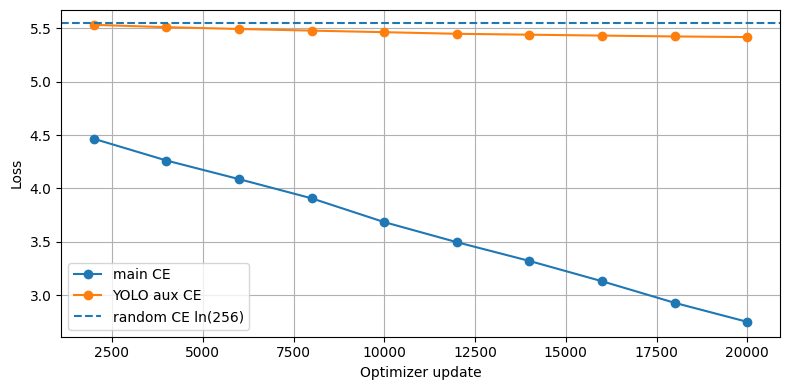

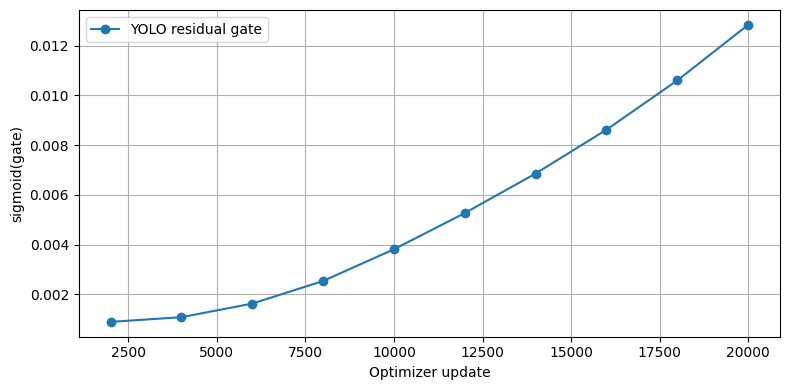

In [39]:
# ============================================================
model.train()
train_iter = infinite_loader(train_loader)

loss_window = []
main_window = []
hw_window = []
bit_window = []
yolo_window = []
gate_window = []
acc_window = []
grad_window = []

pbar = tqdm(range(start_step + 1, TRAIN_STEPS + 1), desc="Training updates")

for step in pbar:
    lr = set_lr(step)
    optimizer.zero_grad(set_to_none=True)

    update_loss = 0.0
    update_main = 0.0
    update_hw = 0.0
    update_bit = 0.0
    update_yolo = 0.0
    update_gate = 0.0
    update_acc = 0.0

    for micro_step in range(GRAD_ACCUM_STEPS):
        traces, labels, hw_labels, bit_labels = next(train_iter)
        traces = traces.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        hw_labels = hw_labels.to(DEVICE, non_blocking=True)
        bit_labels = bit_labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            outputs = model(traces, return_aux=True)
            main_loss = criterion_cls(outputs["logits"], labels)
            hw_loss = criterion_hw(outputs["hw_logits"], hw_labels)
            bit_loss = criterion_bits(outputs["bit_logits"], bit_labels)
            yolo_loss = criterion_cls(outputs["yolo_logits"], labels)
            gate_l1 = torch.sigmoid(model.yolo_gate).float()
            loss = (
                main_loss
                + HW_AUX_WEIGHT * hw_loss
                + BIT_AUX_WEIGHT * bit_loss
                + YOLO_AUX_WEIGHT * yolo_loss
                + GATE_L1_WEIGHT * gate_l1
            )
            loss_for_backward = loss / GRAD_ACCUM_STEPS

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite loss at step {step}: {loss.item()}")

        scaler.scale(loss_for_backward).backward()

        with torch.no_grad():
            acc = (outputs["logits"].argmax(dim=1) == labels).float().mean().item()

        update_loss += float(loss.item())
        update_main += float(main_loss.item())
        update_hw += float(hw_loss.item())
        update_bit += float(bit_loss.item())
        update_yolo += float(yolo_loss.item())
        update_gate += float(outputs["yolo_gate"].detach().float().cpu())
        update_acc += float(acc)

    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    scaler.step(optimizer)
    scaler.update()

    update_loss /= GRAD_ACCUM_STEPS
    update_main /= GRAD_ACCUM_STEPS
    update_hw /= GRAD_ACCUM_STEPS
    update_bit /= GRAD_ACCUM_STEPS
    update_yolo /= GRAD_ACCUM_STEPS
    update_gate /= GRAD_ACCUM_STEPS
    update_acc /= GRAD_ACCUM_STEPS

    loss_window.append(update_loss)
    main_window.append(update_main)
    hw_window.append(update_hw)
    bit_window.append(update_bit)
    yolo_window.append(update_yolo)
    gate_window.append(update_gate)
    acc_window.append(update_acc)
    grad_window.append(float(grad_norm))

    if len(loss_window) > 200:
        loss_window.pop(0); main_window.pop(0); hw_window.pop(0); bit_window.pop(0); yolo_window.pop(0); gate_window.pop(0); acc_window.pop(0); grad_window.pop(0)

    if step % 100 == 0:
        pbar.set_postfix({
            "main": np.mean(main_window),
            "yolo": np.mean(yolo_window),
            "gate": np.mean(gate_window),
            "acc": np.mean(acc_window),
            "lr": lr,
            "gnorm": np.mean(grad_window),
            "samples_M": step * EFFECTIVE_BATCH_SIZE / 1e6,
        })

    if step % SAVE_EVERY_STEPS == 0 or step == TRAIN_STEPS:
        row = {
            "step": int(step),
            "samples_seen": int(step * EFFECTIVE_BATCH_SIZE),
            "loss200": float(np.mean(loss_window)),
            "main_loss200": float(np.mean(main_window)),
            "hw_loss200": float(np.mean(hw_window)),
            "bit_loss200": float(np.mean(bit_window)),
            "yolo_aux_loss200": float(np.mean(yolo_window)),
            "yolo_gate200": float(np.mean(gate_window)),
            "acc200": float(np.mean(acc_window)),
            "lr": float(lr),
            "grad_norm200": float(np.mean(grad_window)),
            "train_batch_size": int(TRAIN_BATCH_SIZE),
            "grad_accum_steps": int(GRAD_ACCUM_STEPS),
            "effective_batch_size": int(EFFECTIVE_BATCH_SIZE),
        }
        history.append(row)
        pd.DataFrame(history).to_csv(RESULT_DIR / "training_history.csv", index=False)
        save_checkpoint(step, "last.pt")
        save_checkpoint(step, f"step_{step}.pt")
        print("Saved checkpoint:", row)

hist = pd.DataFrame(history)
display(hist.tail(20))

plt.figure(figsize=(8, 4))
plt.plot(hist["step"], hist["main_loss200"], marker="o", label="main CE")
plt.plot(hist["step"], hist["yolo_aux_loss200"], marker="o", label="YOLO aux CE")
plt.axhline(np.log(256), linestyle="--", label="random CE ln(256)")
plt.xlabel("Optimizer update")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "training_loss.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(hist["step"], hist["yolo_gate200"], marker="o", label="YOLO residual gate")
plt.xlabel("Optimizer update")
plt.ylabel("sigmoid(gate)")
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "yolo_gate.png", dpi=180)
plt.show()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    


Checkpoints:
 - step_2000.pt
 - step_4000.pt
 - step_6000.pt
 - step_8000.pt
 - step_10000.pt
 - step_12000.pt
 - step_14000.pt
 - step_16000.pt
 - step_18000.pt
 - step_20000.pt

Evaluating checkpoint: step_2000.pt


Predict step_2000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/30 [00:00<?, ?it/s]

{'checkpoint': 'step_2000.pt', 'step': 2000, 'attack_acc': 0.0037, 'single_final_rank': 10, 'single_min_rank': 0, 'single_traces_to_rank0': 794, 'ge_final': 48.03333333333333, 'ge_min': 46.96666666666667, 'traces_to_ge_below_1': None}

Evaluating checkpoint: step_4000.pt


Predict step_4000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

...

{'checkpoint': 'step_18000.pt', 'step': 18000, 'attack_acc': 0.0047, 'single_final_rank': 2, 'single_min_rank': 2, 'single_traces_to_rank0': None, 'ge_final': 40.43333333333333, 'ge_min': 38.733333333333334, 'traces_to_ge_below_1': None}

Evaluating checkpoint: step_20000.pt


Predict step_20000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/30 [00:00<?, ?it/s]

{'checkpoint': 'step_20000.pt', 'step': 20000, 'attack_acc': 0.0044, 'single_final_rank': 3, 'single_min_rank': 3, 'single_traces_to_rank0': None, 'ge_final': 42.6, 'ge_min': 41.666666666666664, 'traces_to_ge_below_1': None}


,checkpoint,step,attack_acc,single_final_rank,single_min_rank,single_traces_to_rank0,ge_final,ge_min,traces_to_ge_below_1
0,step_2000.pt,2000,0.0037,10,0,794.0,48.033333,46.966667,None
1,step_4000.pt,4000,0.0049,18,2,NaN,48.600000,47.366667,None
2,step_6000.pt,6000,0.0038,10,1,NaN,45.933333,44.966667,None
3,step_8000.pt,8000,0.0036,29,0,5.0,69.833333,67.566667,None
4,step_10000.pt,10000,0.0038,12,0,3.0,47.100000,45.066667,None
5,step_12000.pt,12000,0.0040,4,0,6970.0,44.033333,43.200000,None
6,step_14000.pt,14000,0.0036,1,1,NaN,31.566667,30.233333,None
7,step_16000.pt,16000,0.0034,2,1,NaN,35.033333,34.633333,None
8,step_18000.pt,18000,0.0047,2,2,NaN,40.433333,38.733333,None
9,step_20000.pt,20000,0.0044,3,3,NaN,42.600000,41.666667,None


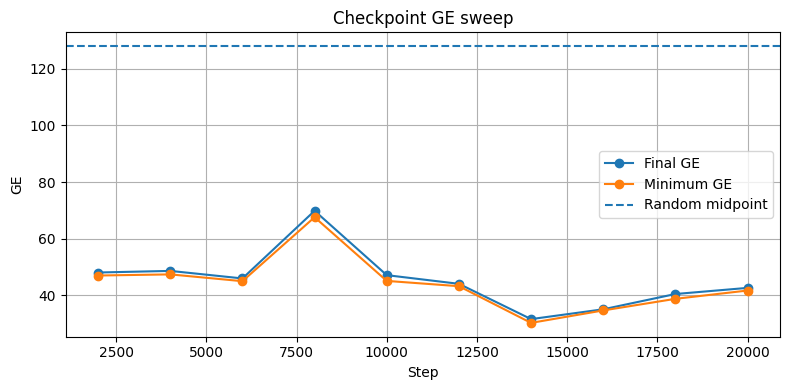

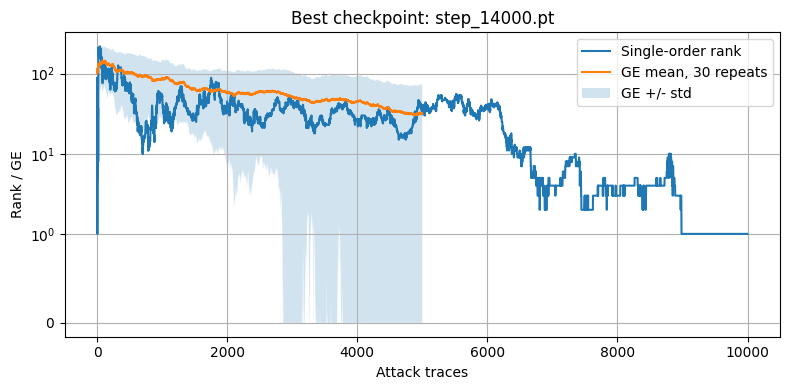

{
  "model_tag": "yologated_hdt_desync100_standard_d128_w50_bs64x4_norm-global_gate-7.0_aug0",
  "dataset_tag": "desync100",
  "ascad_path": "/kaggle/input/datasets/govindkag1/ascad-dataset/ASCAD_data/ASCAD_databases/ASCAD_desync100.h5",
  "true_key": 224,
  "best_checkpoint": {
    "checkpoint": "step_14000.pt",
    "step": 14000,
    "attack_acc": 0.0036,
    "single_final_rank": 1,
    "single_min_rank": 1,
    "single_traces_to_rank0": null,
    "ge_final": 31.566666666666666,
    "ge_min": 30.233333333333334,
    "traces_to_ge_below_1": null
  },
  "num_params": 2532682,
  "norm_mode": "global",
  "aug_shift": 0,
  "effective_batch_size": 256,
  "hw_aux_weight": 0.2,
  "bit_aux_weight": 0.05,
  "yolo_aux_weight": 0.03,
  "gate_l1_weight": 0.0001,
  "trace_image_mode": "raw_window3",
  "yolo_window_len": 64,
  "yolo_window_hop": 8,
  "yolo_gate": 0.012956286780536175,
  "base_hdt_loaded_path": "/kaggle/input/datasets/govindkag1/step-66k/step_66000.pt"
}


In [40]:
# ============================================================
@torch.no_grad()
def predict_logits(model, loader, desc="Predict"):
    model.eval()
    all_logits = []
    all_labels = []
    for batch in tqdm(loader, desc=desc, leave=False):
        traces, labels = batch[0], batch[1]
        traces = traces.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            logits = model(traces, return_aux=False)
        all_logits.append(logits.float().cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_logits, axis=0), np.concatenate(all_labels, axis=0)


def checkpoint_sort_key(path):
    m = re.search(r"step_(\d+)", path.name)
    if m:
        return int(m.group(1))
    if path.name == "last.pt":
        return 10**12
    return -1


def load_checkpoint_for_eval(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"], strict=True)
    return int(ckpt.get("step", checkpoint_sort_key(path)))


def evaluate_checkpoint(path, n_repeats=N_RANK_REPEATS, n_traces=ATTACK_TRACES_FOR_GE):
    step = load_checkpoint_for_eval(path)
    logits, labels = predict_logits(model, attack_loader, desc=f"Predict {path.name}")
    log_probs = stable_log_softmax_np(logits)

    pred = logits.argmax(axis=1)
    attack_acc = float(np.mean(pred == y_attack))

    single_curve = rank_curve_from_log_probs(log_probs, attack_plain, ATTACK_TRUE_KEY)
    ge_mean, ge_std, ge_curves = guessing_entropy_from_log_probs(
        log_probs,
        attack_plain,
        ATTACK_TRUE_KEY,
        n_traces=min(n_traces, len(log_probs)),
        n_repeats=n_repeats,
        seed=SEED + 777,
    )
    metrics = metrics_from_ge(single_curve, ge_mean)
    row = {
        "checkpoint": path.name,
        "step": int(step),
        "attack_acc": attack_acc,
        **metrics,
    }
    return row, single_curve, ge_mean, ge_std, logits

ckpt_paths = sorted(list(CKPT_DIR.glob("step_*.pt")), key=checkpoint_sort_key)
if len(ckpt_paths) == 0 and (CKPT_DIR / "last.pt").exists():
    ckpt_paths = [CKPT_DIR / "last.pt"]

print("Checkpoints:")
for p in ckpt_paths:
    print(" -", p.name)

if len(ckpt_paths) == 0:
    raise FileNotFoundError(f"No checkpoints found in {CKPT_DIR}")

sweep_rows = []
best = None

for p in ckpt_paths:
    print("\nEvaluating checkpoint:", p.name)
    row, single_curve, ge_mean, ge_std, logits = evaluate_checkpoint(p)
    sweep_rows.append(row)
    print(row)
    if best is None or row["ge_final"] < best["row"]["ge_final"]:
        best = {"row": row, "path": p, "single_curve": single_curve, "ge_mean": ge_mean, "ge_std": ge_std, "logits": logits}

sweep_df = pd.DataFrame(sweep_rows).sort_values("step")
display(sweep_df)
sweep_df.to_csv(RESULT_DIR / "checkpoint_rank_ge_sweep.csv", index=False)

plt.figure(figsize=(8, 4))
plt.plot(sweep_df["step"], sweep_df["ge_final"], marker="o", label="Final GE")
plt.plot(sweep_df["step"], sweep_df["ge_min"], marker="o", label="Minimum GE")
plt.axhline(128, linestyle="--", label="Random midpoint")
plt.xlabel("Step")
plt.ylabel("GE")
plt.title("Checkpoint GE sweep")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "checkpoint_ge_sweep.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(best["single_curve"], label="Single-order rank")
plt.plot(best["ge_mean"], label=f"GE mean, {N_RANK_REPEATS} repeats")
plt.fill_between(
    np.arange(len(best["ge_mean"])),
    np.maximum(best["ge_mean"] - best["ge_std"], 0),
    best["ge_mean"] + best["ge_std"],
    alpha=0.2,
    label="GE +/- std",
)
plt.xlabel("Attack traces")
plt.ylabel("Rank / GE")
plt.yscale("symlog", linthresh=1)
plt.title(f"Best checkpoint: {best['path'].name}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "best_rank_ge_curve.png", dpi=180)
plt.show()

summary = {
    "model_tag": MODEL_TAG,
    "dataset_tag": DATASET_TAG,
    "ascad_path": ASCAD_PATH,
    "true_key": int(ATTACK_TRUE_KEY),
    "best_checkpoint": best["row"],
    "num_params": int(num_params),
    "norm_mode": NORM_MODE,
    "aug_shift": int(AUG_SHIFT),
    "effective_batch_size": int(EFFECTIVE_BATCH_SIZE),
    "hw_aux_weight": float(HW_AUX_WEIGHT),
    "bit_aux_weight": float(BIT_AUX_WEIGHT),
    "yolo_aux_weight": float(YOLO_AUX_WEIGHT),
    "gate_l1_weight": float(GATE_L1_WEIGHT),
    "trace_image_mode": TRACE_IMAGE_MODE,
    "yolo_window_len": int(YOLO_WINDOW_LEN),
    "yolo_window_hop": int(YOLO_WINDOW_HOP),
    "yolo_gate": float(torch.sigmoid(model.yolo_gate).detach().cpu()),
    "base_hdt_loaded_path": str(base_hdt_loaded_path) if base_hdt_loaded_path is not None else None,
}
with open(RESULT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))
